# Exploration Strategies: Epsilon-Greedy

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand the exploration-exploitation dilemma
- Implement Epsilon-Greedy exploration strategy
- Visualize the impact of different epsilon values
- Compare exploration vs exploitation behavior
- Apply Epsilon-Greedy to RL problems

## 🔗 Prerequisites

- ✅ OpenAI Gym setup (previous notebook)
- ✅ Understanding of RL basics (actions, rewards, policies)
- ✅ Python knowledge (functions, loops, matplotlib)
- ✅ NumPy knowledge

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 1**:
- Exploration strategies: programming Epsilon-Greedy strategy and visualizing its impact

---

## Introduction

**Exploration-Exploitation Dilemma**: RL agents must balance exploring new actions (to discover better rewards) with exploiting known good actions (to maximize rewards). **Epsilon-Greedy** is a simple but effective exploration strategy.

## Lesson Brief

This lesson explains the exploration-exploitation dilemma through the simplest practical strategy: **epsilon-greedy**.

Students will see why an agent cannot only exploit what it already knows, and why some controlled exploration is necessary for learning.

Why this matters: this idea appears again in Q-learning, bandits, and deep RL.

If students understand this lesson well, many later design choices become easier to explain.

## What you should learn from this notebook

By the end of this notebook, you should be able to:

- explain the exploration-exploitation dilemma in plain language
- implement epsilon-greedy action selection
- understand how epsilon changes behavior
- use epsilon decay during learning
- recognize why this strategy is simple, useful, and imperfect


In [1]:
%pip install "gymnasium[classic_control]" numpy matplotlib -q
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym  # successor to OpenAI Gym; API-compatible for imports

print("✅ Libraries imported!")
print("\nExploration Strategies: Epsilon-Greedy")
print("=" * 60)

You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


✅ Libraries imported!

Exploration Strategies: Epsilon-Greedy


## Part 1: Understanding Epsilon-Greedy Strategy


In [2]:
print("=" * 60)
print("Part 1: Understanding Epsilon-Greedy Strategy")
print("=" * 60)

print("\nEpsilon-Greedy Algorithm:")
print("  1. With probability ε (epsilon): Explore (choose random action)")
print("  2. With probability 1-ε: Exploit (choose best known action)")

print("\nKey Parameters:")
print("  - ε (epsilon): Exploration rate (0.0 to 1.0)")
print("  - ε = 1.0: Pure exploration (always random)")
print("  - ε = 0.0: Pure exploitation (always greedy)")
print("  - ε = 0.1: 10% exploration, 90% exploitation (common choice)")

print("\nEpsilon Decay:")
print("  - Start with high ε (more exploration)")
print("  - Gradually decrease ε (more exploitation as agent learns)")
print("  - Common: ε = 1.0 → 0.01 over training")

print("\n✅ Epsilon-Greedy strategy understood!")

Part 1: Understanding Epsilon-Greedy Strategy

Epsilon-Greedy Algorithm:
  1. With probability ε (epsilon): Explore (choose random action)
  2. With probability 1-ε: Exploit (choose best known action)

Key Parameters:
  - ε (epsilon): Exploration rate (0.0 to 1.0)
  - ε = 1.0: Pure exploration (always random)
  - ε = 0.0: Pure exploitation (always greedy)
  - ε = 0.1: 10% exploration, 90% exploitation (common choice)

Epsilon Decay:
  - Start with high ε (more exploration)
  - Gradually decrease ε (more exploitation as agent learns)
  - Common: ε = 1.0 → 0.01 over training

✅ Epsilon-Greedy strategy understood!


## Part 2: Implementing Epsilon-Greedy


In [3]:
print("\n" + "=" * 60)
print("Part 2: Implementing Epsilon-Greedy")
print("=" * 60)


def epsilon_greedy_action(q_values, epsilon, n_actions):
    """Return (action, mode) where mode is 'explore' or 'exploit'."""
    if np.random.random() < epsilon:
        return np.random.randint(n_actions), "explore"
    return int(np.argmax(q_values)), "exploit"


# Example: a tiny bandit-style decision problem
n_actions = 4
q_values = np.array([0.1, 0.3, 0.5, 0.2])
epsilon = 0.3

print(f"\nExample estimated values: {q_values}")
print(f"Epsilon: {epsilon}")
print("\nRunning epsilon-greedy for 20 steps:")

action_counts = np.zeros(n_actions)
mode_counts = {"explore": 0, "exploit": 0}
for i in range(20):
    action, mode = epsilon_greedy_action(q_values, epsilon, n_actions)
    action_counts[action] += 1
    mode_counts[mode] += 1
    print(f"  Step {i + 1}: Action {action} ({mode})")

print("\nAction selection counts:")
for i in range(n_actions):
    print(f"  Action {i}: {int(action_counts[i])} times ({action_counts[i] / 20 * 100:.1f}%)")

best_action = int(np.argmax(q_values))
print(f"\nBest current action: {best_action}")
print(f"Explore decisions: {mode_counts['explore']}")
print(f"Exploit decisions: {mode_counts['exploit']}")
print("\nCheckpoint: even when one action looks best, epsilon-greedy still tries")
print("other actions sometimes so the agent can discover better choices later.")


Part 2: Implementing Epsilon-Greedy

Example estimated values: [0.1 0.3 0.5 0.2]
Epsilon: 0.3

Running epsilon-greedy for 20 steps:
  Step 1: Action 2 (explore)
  Step 2: Action 2 (exploit)
  Step 3: Action 2 (exploit)
  Step 4: Action 2 (exploit)
  Step 5: Action 3 (explore)
  Step 6: Action 2 (exploit)
  Step 7: Action 2 (exploit)
  Step 8: Action 2 (exploit)
  Step 9: Action 2 (exploit)
  Step 10: Action 2 (exploit)
  Step 11: Action 2 (exploit)
  Step 12: Action 2 (exploit)
  Step 13: Action 2 (exploit)
  Step 14: Action 2 (exploit)
  Step 15: Action 2 (exploit)
  Step 16: Action 2 (exploit)
  Step 17: Action 2 (exploit)
  Step 18: Action 1 (explore)
  Step 19: Action 2 (exploit)
  Step 20: Action 3 (explore)

Action selection counts:
  Action 0: 0 times (0.0%)
  Action 1: 1 times (5.0%)
  Action 2: 17 times (85.0%)
  Action 3: 2 times (10.0%)

Best current action: 2
Explore decisions: 4
Exploit decisions: 16

Checkpoint: even when one action looks best, epsilon-greedy still tries

## Part 3: Visualizing Impact of Different Epsilon Values



Part 3: Visualizing Impact of Different Epsilon Values

Action selection percentages for different epsilon values:
Action | ε=0.0 | ε=0.1 | ε=0.3 | ε=0.5 | ε=1.0
--------------------------------------------------
  0 | 0.0% | 3.2% | 7.7% | 12.2% | 23.4%
  1 | 0.0% | 2.9% | 7.5% | 13.2% | 25.9%
  2 | 100.0% | 91.7% | 76.6% | 63.1% | 26.1% <- best estimate
  3 | 0.0% | 2.2% | 8.2% | 11.5% | 24.6%


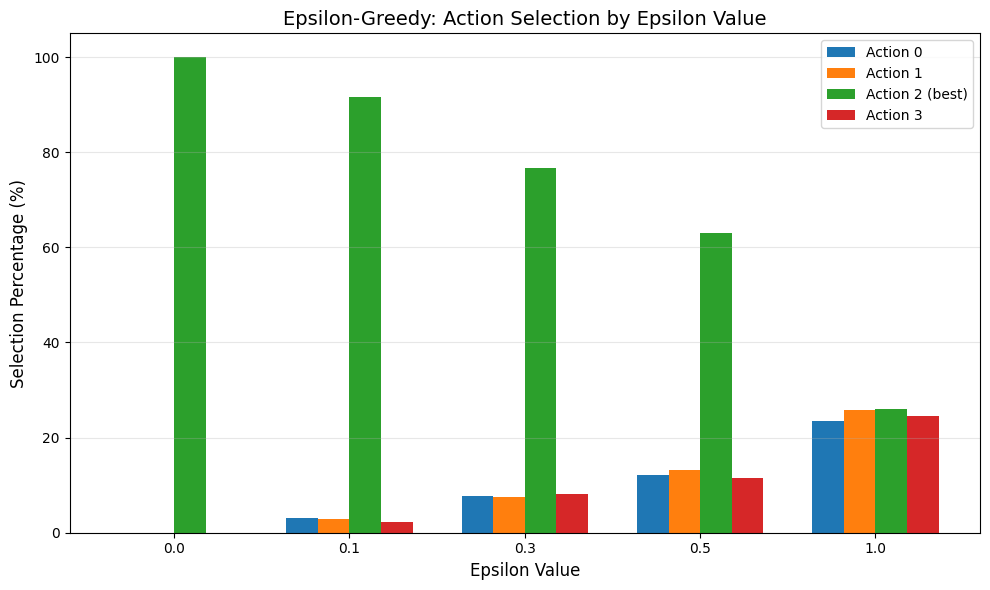


✅ Impact visualization complete!


In [4]:
print("\n" + "=" * 60)
print("Part 3: Visualizing Impact of Different Epsilon Values")
print("=" * 60)

# Test different epsilon values
epsilon_values = [0.0, 0.1, 0.3, 0.5, 1.0]
n_steps = 1000
n_actions = 4
q_values = np.array([0.1, 0.3, 0.5, 0.2])
best_action = int(np.argmax(q_values))

results = {}

for epsilon in epsilon_values:
    action_counts = np.zeros(n_actions)
    for _ in range(n_steps):
        action, _ = epsilon_greedy_action(q_values, epsilon, n_actions)
        action_counts[action] += 1
    results[epsilon] = action_counts / n_steps

print("\nAction selection percentages for different epsilon values:")
print("Action | ε=0.0 | ε=0.1 | ε=0.3 | ε=0.5 | ε=1.0")
print("-" * 50)
for i in range(n_actions):
    percentages = [f"{results[eps][i] * 100:.1f}%" for eps in epsilon_values]
    marker = " <- best estimate" if i == best_action else ""
    print(f"  {i} | {' | '.join(percentages)}{marker}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(epsilon_values))
width = 0.18

for i in range(n_actions):
    percentages = [results[eps][i] * 100 for eps in epsilon_values]
    label = f"Action {i}" + (" (best)" if i == best_action else "")
    ax.bar(x + i * width, percentages, width, label=label)

ax.set_xlabel('Epsilon Value', fontsize=12)
ax.set_ylabel('Selection Percentage (%)', fontsize=12)
ax.set_title('Epsilon-Greedy: Action Selection by Epsilon Value', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([str(eps) for eps in epsilon_values])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n✅ Impact visualization complete!")

## Part 4: Epsilon Decay Strategy



Part 4: Epsilon Decay Strategy


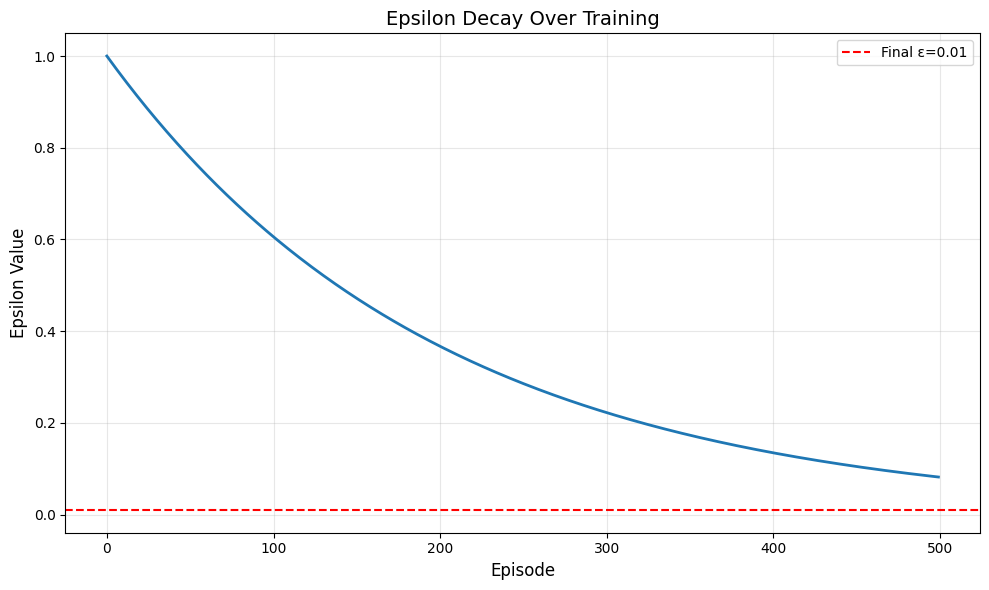


Epsilon Decay:
  Initial ε: 1.0
  Final ε: 0.01
  Decay rate: 0.995
  Episodes: 500
  ε at episode 100: 0.6058
  ε at episode 250: 0.2856
  ε at episode 500: 0.0820

✅ Epsilon decay strategy complete!


In [5]:
print("\n" + "=" * 60)
print("Part 4: Epsilon Decay Strategy")
print("=" * 60)

def epsilon_decay(initial_epsilon, final_epsilon, decay_rate, episode):
    """
    Calculate epsilon with exponential decay.
    
    Args:
        initial_epsilon: Starting epsilon value
        final_epsilon: Minimum epsilon value
        decay_rate: Decay rate (0.0 to 1.0)
        episode: Current episode number
    
    Returns:
        Decayed epsilon value
    """
    return max(final_epsilon, initial_epsilon * (decay_rate ** episode))

# Simulate epsilon decay over training
initial_epsilon = 1.0
final_epsilon = 0.01
decay_rate = 0.995
n_episodes = 500

epsilon_history = []
for episode in range(n_episodes):
    epsilon = epsilon_decay(initial_epsilon, final_epsilon, decay_rate, episode)
    epsilon_history.append(epsilon)

# Visualize epsilon decay
plt.figure(figsize=(10, 6))
plt.plot(epsilon_history, linewidth=2)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Epsilon Value', fontsize=12)
plt.title('Epsilon Decay Over Training', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=final_epsilon, color='r', linestyle='--', label=f'Final ε={final_epsilon}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nEpsilon Decay:")
print(f"  Initial ε: {initial_epsilon}")
print(f"  Final ε: {final_epsilon}")
print(f"  Decay rate: {decay_rate}")
print(f"  Episodes: {n_episodes}")
print(f"  ε at episode 100: {epsilon_history[100]:.4f}")
print(f"  ε at episode 250: {epsilon_history[250]:.4f}")
print(f"  ε at episode 500: {epsilon_history[499]:.4f}")

print("\n✅ Epsilon decay strategy complete!")

## Worked Example: A Small Bandit Problem

A bandit problem is a clean way to understand exploration.

Imagine a website team testing several button designs. Each design has an unknown
click-through rate. The system must decide:

- should it keep showing the design that currently looks best?
- or should it still test other designs in case one is better?

That is exactly the exploration-exploitation dilemma.


Epsilon = 0.0
 Arm pulls: [500   0   0]
 Estimated values: [0.126 0.    0.   ]
 Average reward: 0.126

Epsilon = 0.1
 Arm pulls: [ 53 377  70]
 Estimated values: [0.17  0.329 0.257]
 Average reward: 0.302

Epsilon = 0.3
 Arm pulls: [ 46 402  52]
 Estimated values: [0.152 0.366 0.346]
 Average reward: 0.344


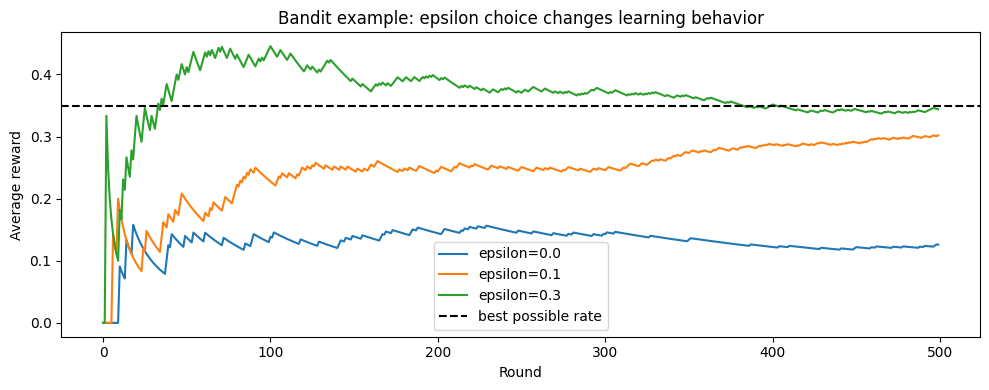


Teaching point:
- epsilon=0.0 can get stuck exploiting too early.
- a small epsilon often learns more safely.
- a very large epsilon explores a lot, but may exploit too slowly.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
TRUE_RATES = np.array([0.15, 0.35, 0.25])
N_ARMS = len(TRUE_RATES)
N_ROUNDS = 500


def pull(arm):
    return 1 if np.random.rand() < TRUE_RATES[arm] else 0


def run_epsilon_greedy(epsilon):
    counts = np.zeros(N_ARMS)
    value_estimates = np.zeros(N_ARMS)
    rewards = []

    for _ in range(N_ROUNDS):
        action, _ = epsilon_greedy_action(value_estimates, epsilon, N_ARMS)
        reward = pull(action)
        counts[action] += 1
        value_estimates[action] += (reward - value_estimates[action]) / counts[action]
        rewards.append(reward)

    return counts, value_estimates, np.array(rewards)


results = {}
for epsilon in [0.0, 0.1, 0.3]:
    counts, estimates, rewards = run_epsilon_greedy(epsilon)
    results[epsilon] = (counts, estimates, rewards)
    print(f"\nEpsilon = {epsilon}")
    print(" Arm pulls:", counts.astype(int))
    print(" Estimated values:", np.round(estimates, 3))
    print(" Average reward:", rewards.mean().round(3))

plt.figure(figsize=(10, 4))
for epsilon, (_, _, rewards) in results.items():
    running_average = np.cumsum(rewards) / np.arange(1, len(rewards) + 1)
    plt.plot(running_average, label=f"epsilon={epsilon}")
plt.axhline(TRUE_RATES.max(), linestyle="--", color="black", label="best possible rate")
plt.xlabel("Round")
plt.ylabel("Average reward")
plt.title("Bandit example: epsilon choice changes learning behavior")
plt.legend()
plt.tight_layout()
plt.show()

print("\nTeaching point:")
print("- epsilon=0.0 can get stuck exploiting too early.")
print("- a small epsilon often learns more safely.")
print("- a very large epsilon explores a lot, but may exploit too slowly.")

## Summary

You learned the first core exploration strategy used throughout RL:

- **epsilon-greedy** explores with probability `epsilon`
- otherwise it exploits the best current action estimate

### What to remember

- Exploration is necessary because the agent does not know the best action at the start.
- Exploitation is necessary because the agent must eventually use what it has learned.
- Epsilon decay is a practical way to move from more exploration to more exploitation over time.

### Important limitation

Epsilon-greedy is simple and useful, but it is not always the most efficient strategy.
More advanced exploration methods appear later in Unit 4.

### Next step

Move to `06_solving_rl_problems_states_actions_rewards.ipynb` or, if you already completed it,
continue to `07_mini_projects_cartpole_frozenlake_qlearning_dqn.ipynb`. 

## 📚 References & Further Reading

**Book:** Sutton & Barto — [RL Introduction Ch.2: Multi-armed Bandits](http://incompleteideas.net/book/the-book-2nd.html)
**Paper:** Auer et al. (2002) — [Finite-time Analysis of UCB](https://link.springer.com/article/10.1023/A:1013689704352)

**Real-World Usage:**
- Google uses Thompson Sampling in Google Ads for A/B testing at scale
- Netflix uses bandit algorithms to pick which thumbnail to show each user

**State-of-the-Art:** ε-greedy and UCB are still dominant in industry A/B testing systems.

## Closing Takeaway

**Teaching takeaway:** Epsilon-greedy balances trying what looks best now with occasionally exploring alternatives that may become better later.

**If students remember one idea:** Exploration is not randomness for its own sake. It is a strategy for avoiding premature confidence.

**Quick check before moving on:**
- Can you explain what happens when epsilon is too high or too low?
- Can you tell when an action was chosen for exploration versus exploitation?

**Bridge to the next step:** Next, you will step back and learn how to formulate RL problems before choosing the right algorithm.
